# Unidad 1 · Capacidad de proceso: Cp, Cpk, Pp, Ppk

**Planta:** Conservas del Itata S.A. — llenado del formato de 480 g
**Datos:** `DatosClases/1_Calidad/itata_peso.csv` (30 subgrupos de n = 4)

---

## Qué se decide aquí

El cuaderno anterior terminó con una advertencia: un proceso puede estar
**en control** y producir fuera de especificación todo el día. Control y
capacidad son preguntas distintas y se responden con datos distintos:

| pregunta | herramienta | compara contra |
|---|---|---|
| ¿cambió algo? | carta de control | la voz del **proceso** |
| ¿alcanza para lo que el cliente pide? | índice de capacidad | la voz del **cliente** |

La decisión que cuelga de aquí no es «intervenir o no», sino una de tres:
dejar el proceso como está, **recentrarlo**, o **reducir su variabilidad**.
Son tres decisiones con costos muy distintos, y el aporte de los índices es
decir cuál de las tres corresponde. Recentrar suele ser un ajuste de
dosificador; reducir sigma suele ser un proyecto de inversión.

La especificación del formato es: nominal 480 g declarado en el envase,
LIE 465 g, LSE 495 g, de modo que la tolerancia es de 30 g. El límite
inferior no es un capricho de ingeniería: por debajo de él el envase declara
un peso que no entrega, y eso es un problema legal, no de calidad percibida.

## Por qué solo Fase I

Toda la capacidad se calcula con los subgrupos 1–20. La razón es la misma que
hace que las cartas funcionen: un índice de capacidad es una **predicción**
sobre la producción futura, y una predicción supone que el proceso seguirá
comportándose como lo hizo. En Fase II la media se corrió de 486 a 492 g; ahí
no hay un proceso, hay dos. Calcular Cp sobre la mezcla daría un número que no
describe ni al proceso de antes ni al de después: describiría el promedio de
un accidente. Estimar capacidad sobre un proceso fuera de control no es una
aproximación tosca — es una operación sin significado.

## Cifras de referencia

| cantidad | valor |
|---|---|
| σ corto plazo (R̄/d₂) | 3,655 g |
| σ largo plazo (s muestral) | 3,962 g |
| Cp | 1,368 |
| Cpu / Cpl | 0,840 / 1,896 |
| Cpk | 0,840 |
| Pp / Ppk | 1,262 / 0,775 |
| k (descentrado) | 0,386 |
| PPM total esperado | 5 891 |
| sobrepeso medio | +5,79 g por envase |
| al recentrar en 480 g | Cpk 0,84 → 1,37 y PPM 5 891 → 41 |

In [1]:
import sys
from pathlib import Path

sys.path.append(str(Path.cwd().parent))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

from comun import datos, tabla, figura, resumen, verificar, estilo

estilo()

NOMINAL, LIE, LSE = 480.0, 465.0, 495.0
TOLERANCIA = LSE - LIE
CENTRO_ESPEC = (LIE + LSE) / 2

peso = pd.read_csv(datos("1_Calidad", "itata_peso.csv"))
fase1 = peso[peso.fase == "I"]

print(f"Especificación: nominal {NOMINAL:.0f} g   "
      f"[LIE {LIE:.0f} ; LSE {LSE:.0f}]   tolerancia {TOLERANCIA:.0f} g")
print(f"Fase I: {fase1.subgrupo.nunique()} subgrupos · {len(fase1)} observaciones")
fase1.head()

Especificación: nominal 480 g   [LIE 465 ; LSE 495]   tolerancia 30 g
Fase I: 20 subgrupos · 80 observaciones


,subgrupo,fase,turno,n_obs,peso_g
0,1,I,A (06-14),1,475.15
1,1,I,A (06-14),2,478.34
2,1,I,A (06-14),3,488.49
3,1,I,A (06-14),4,491.77
4,2,I,B (14-22),1,489.36


## 1. Dos sigmas, y por qué no son el mismo número

Aquí está la distinción que más confusión produce en el curso, y conviene
hacerla despacio porque de ella salen dos familias de índices.

* **σ de corto plazo** se estima *dentro* de los subgrupos: R̄/d₂. Como los
  cuatro envases de un subgrupo se tomaron juntos, entre ellos casi no hubo
  tiempo para que cambiaran la temperatura, el operador o el lote de materia
  prima. Lo que queda es la variación instantánea de la máquina: lo que el
  proceso es **capaz** de hacer en su mejor día.
* **σ de largo plazo** se estima con la desviación muestral de *todas* las
  observaciones juntas, sin mirar a qué subgrupo pertenecen. Ahí entra también
  el movimiento de la media de un subgrupo a otro: lo que el proceso
  efectivamente **hace** a lo largo de un turno.

La aritmética garantiza que el segundo sea mayor o igual que el primero: la
varianza total es la variación dentro más la variación entre. La diferencia
entre ambos es la medida directa de cuánta inestabilidad queda todavía. Si los
dos números fueran iguales, el proceso sería perfectamente homogéneo en el
tiempo. Aquí no lo son, y esa brecha reaparecerá como la brecha entre Cp y Pp.

In [2]:
CONST = {2: dict(d2=1.128), 3: dict(d2=1.693),
         4: dict(d2=2.059), 5: dict(d2=2.326)}

n = int(peso.groupby("subgrupo").size().iloc[0])
d2 = CONST[n]["d2"]

sg1 = fase1.groupby("subgrupo")["peso_g"]
xbb = sg1.mean().mean()
rbar = (sg1.max() - sg1.min()).mean()

sigma_corto = rbar / d2
sigma_largo = fase1["peso_g"].std(ddof=1)

print(f"  X-doble-barra (Fase I)       = {xbb:.3f} g")
print(f"  R-barra (Fase I)             = {rbar:.3f} g")
print(f"\n  sigma corto plazo = R-barra/d2 = {rbar:.3f}/{d2} = {sigma_corto:.3f} g")
print(f"  sigma largo plazo = s muestral de las {len(fase1)} obs. "
      f"= {sigma_largo:.3f} g")
print(f"\n  El largo plazo es {100*(sigma_largo/sigma_corto - 1):.1f} % mayor: "
      f"esa es la inestabilidad que queda entre subgrupos.")

  X-doble-barra (Fase I)       = 485.794 g
  R-barra (Fase I)             = 7.526 g

  sigma corto plazo = R-barra/d2 = 7.526/2.059 = 3.655 g
  sigma largo plazo = s muestral de las 80 obs. = 3.962 g

  El largo plazo es 8.4 % mayor: esa es la inestabilidad que queda entre subgrupos.


## 2. Cp: cuánto cabe la especificación dentro del proceso

Cp responde una sola pregunta y la responde bien: ¿el ancho de la
especificación alcanza para el ancho del proceso? Se define como

$$C_p = \frac{LSE - LIE}{6\sigma}$$

El 6σ del denominador es la convención de que un proceso normal «ocupa»
±3σ alrededor de su media, es decir el 99,73 % de lo que produce. Cp = 1
significa que el proceso ocupa exactamente toda la tolerancia, sin holgura:
cualquier corrimiento mínimo empieza a generar rechazos. Por eso la industria
pide Cp ≥ 1,33 como mínimo aceptable y ≥ 1,67 para características críticas.

El punto ciego de Cp es tan importante como su virtud: en la fórmula **no
aparece la media**. Cp mide el ancho del proceso y nada más. Un proceso
angosto ubicado completamente fuera de la especificación tiene un Cp
excelente y produce 100 % de rechazos. Cp es una capacidad *potencial*: lo
que el proceso podría lograr si estuviera bien centrado.

In [3]:
Cp = TOLERANCIA / (6 * sigma_corto)

print(f"  Cp = ({LSE:.0f} - {LIE:.0f}) / (6 x {sigma_corto:.3f}) = {Cp:.3f}")
print(f"\n  El proceso ocupa 6 sigma = {6*sigma_corto:.2f} g "
      f"dentro de una tolerancia de {TOLERANCIA:.0f} g.")
print(f"  Le sobran {TOLERANCIA - 6*sigma_corto:.2f} g de holgura -- "
      f"si estuviera centrado.")

  Cp = (495 - 465) / (6 x 3.655) = 1.368

  El proceso ocupa 6 sigma = 21.93 g dentro de una tolerancia de 30 g.
  Le sobran 8.07 g de holgura -- si estuviera centrado.


## 3. Cpk: el ancho **y** el centrado

Cpk corrige el punto ciego mirando cada lado por separado. Se calcula la
distancia de la media a cada límite en unidades de 3σ,

$$C_{pu} = \frac{LSE - \bar{\bar{X}}}{3\sigma}, \qquad
  C_{pl} = \frac{\bar{\bar{X}} - LIE}{3\sigma}, \qquad
  C_{pk} = \min(C_{pu}, C_{pl})$$

y se toma el peor de los dos, porque el proceso se romperá por el lado más
cercano. Que sea un mínimo no es un detalle técnico: Cpk es, por
construcción, un índice **pesimista**, y esa es exactamente la propiedad que
se quiere en una garantía hacia el cliente.

Aquí la planta llena en promedio 485,79 g contra un nominal de 480 g. Está
corrida hacia arriba, hacia el LSE, y eso va a mostrarse en la asimetría entre
Cpu y Cpl.

In [4]:
Cpu = (LSE - xbb) / (3 * sigma_corto)
Cpl = (xbb - LIE) / (3 * sigma_corto)
Cpk = min(Cpu, Cpl)

marca_u = "   <-- lado crítico" if Cpu < Cpl else ""
marca_l = "   <-- lado crítico" if Cpl < Cpu else ""
print(f"  Cpu = ({LSE:.0f} - {xbb:.3f}) / (3 x {sigma_corto:.3f}) = {Cpu:.3f}{marca_u}")
print(f"  Cpl = ({xbb:.3f} - {LIE:.0f}) / (3 x {sigma_corto:.3f}) = {Cpl:.3f}{marca_l}")
print(f"\n  Cpk = min(Cpu, Cpl) = {Cpk:.3f}")
print(f"\n  Cp  = {Cp:.3f}  (potencial, si estuviera centrado)")
print(f"  Cpk = {Cpk:.3f}  (real, con el centrado que tiene)")
print(f"  Cp / Cpk = {Cp/Cpk:.2f}")

  Cpu = (495 - 485.794) / (3 x 3.655) = 0.840   <-- lado crítico
  Cpl = (485.794 - 465) / (3 x 3.655) = 1.896

  Cpk = min(Cpu, Cpl) = 0.840

  Cp  = 1.368  (potencial, si estuviera centrado)
  Cpk = 0.840  (real, con el centrado que tiene)
  Cp / Cpk = 1.63


El cociente Cp/Cpk = 1,63 es la cifra más útil de esta sección, porque
convierte «el proceso está descentrado» en una cantidad. Si el proceso
estuviera centrado, Cp y Cpk serían iguales y el cociente sería 1. Que sea
1,63 dice que se está perdiendo el 39 % de la capacidad que el proceso ya
tiene, sin haber tocado la máquina. No es que falte capacidad: está, y se
está desperdiciando en el centrado.

## 4. El índice de descentrado k

La relación entre Cp y Cpk se puede escribir de forma exacta. Definiendo

$$k = \frac{|\bar{\bar{X}} - M|}{(LSE-LIE)/2}, \qquad M = \frac{LIE+LSE}{2}$$

es decir, el descentrado medido como fracción de la media tolerancia, se
cumple **Cpk = Cp (1 − k)**. k = 0 es un proceso centrado; k = 1 es un proceso
cuya media cayó justo sobre un límite de especificación, y entonces Cpk = 0.

Que la identidad sea exacta importa didácticamente: separa limpiamente los dos
problemas. Cp es el problema de variabilidad, k es el problema de centrado, y
Cpk los mezcla en un solo número. Un Cpk bajo por sí solo no dice qué hacer;
la pareja (Cp, k) sí.

In [5]:
k = abs(xbb - CENTRO_ESPEC) / (TOLERANCIA / 2)

print(f"  Centro de la especificación M = {CENTRO_ESPEC:.0f} g")
print(f"  Media del proceso             = {xbb:.3f} g")
print(f"  Descentrado                   = {xbb - CENTRO_ESPEC:+.3f} g")
print(f"\n  k = {abs(xbb - CENTRO_ESPEC):.3f} / {TOLERANCIA/2:.0f} = {k:.3f}"
      f"   ({100*k:.1f} % de la media tolerancia)")
print(f"\n  Verificación de la identidad:")
print(f"    Cp (1 - k) = {Cp:.3f} x (1 - {k:.3f}) = {Cp*(1-k):.3f}")
print(f"    Cpk        = {Cpk:.3f}")

  Centro de la especificación M = 480 g
  Media del proceso             = 485.794 g
  Descentrado                   = +5.794 g

  k = 5.794 / 15 = 0.386   (38.6 % de la media tolerancia)

  Verificación de la identidad:
    Cp (1 - k) = 1.368 x (1 - 0.386) = 0.840
    Cpk        = 0.840


## 5. Pp y Ppk: lo que el cliente realmente recibe

Las mismas fórmulas, cambiando σ de corto plazo por σ de largo plazo, dan los
índices de **desempeño** Pp y Ppk. La convención de nombres no es arbitraria:
*capacidad* es lo que el proceso puede hacer, *desempeño* es lo que hizo.

Cp > Pp siempre que haya movimiento entre subgrupos, y la brecha tiene una
lectura de gestión directa: es la parte de la capacidad que se pierde por
inestabilidad, no por la máquina. Cerrar esa brecha no requiere comprar nada;
requiere que el proceso deje de moverse. Es, de nuevo, el argumento de las
cartas de control: la estabilidad no es un fin estético, tiene un valor
medible en índices.

In [6]:
media_lp = fase1["peso_g"].mean()
Pp = TOLERANCIA / (6 * sigma_largo)
Ppk = min((LSE - media_lp) / (3 * sigma_largo),
          (media_lp - LIE) / (3 * sigma_largo))

comparacion = pd.DataFrame({
    "indice": ["Cp / Pp (ancho)", "Cpk / Ppk (ancho y centrado)"],
    "corto_plazo": [Cp, Cpk],
    "largo_plazo": [Pp, Ppk],
})
comparacion["brecha"] = comparacion.corto_plazo - comparacion.largo_plazo

print(comparacion.to_string(index=False, float_format=lambda v: f"{v:8.3f}"))
print(f"\n  La brecha Cp - Pp = {Cp - Pp:.3f} es capacidad perdida por"
      f" inestabilidad,\n  no por la máquina.")

                      indice  corto_plazo  largo_plazo   brecha
             Cp / Pp (ancho)        1.368        1.262    0.106
Cpk / Ppk (ancho y centrado)        0.840        0.775    0.065

  La brecha Cp - Pp = 0.106 es capacidad perdida por inestabilidad,
  no por la máquina.


## 6. De índices a unidades: el PPM esperado

Un índice es una razón sin unidades y por eso es difícil de discutir con quien
no hizo el curso. El PPM (partes por millón fuera de especificación) traduce
el mismo contenido a algo que se puede llevar a una reunión.

El cálculo supone normalidad y usa la distribución acumulada: la fracción
sobre el LSE es P(X > LSE) y la fracción bajo el LIE es P(X < LIE), ambas con
media X̄̄ y desviación σ. Conviene decir en voz alta que el supuesto de
normalidad es *fuerte* precisamente en las colas, que es donde se está
calculando: el PPM es una estimación con orden de magnitud correcto, no una
predicción al entero. Con 80 observaciones no se puede verificar
empíricamente un evento de 6 en mil.

In [7]:
z_sup = (LSE - xbb) / sigma_corto
z_inf = (LIE - xbb) / sigma_corto
ppm_sup = stats.norm.sf(z_sup) * 1e6
ppm_inf = stats.norm.cdf(z_inf) * 1e6
ppm_total = ppm_sup + ppm_inf

print(f"  z al LSE = ({LSE:.0f} - {xbb:.3f}) / {sigma_corto:.3f} = {z_sup:.3f}")
print(f"  z al LIE = ({LIE:.0f} - {xbb:.3f}) / {sigma_corto:.3f} = {z_inf:.3f}")
print(f"\n  PPM sobre LSE (sobrellenado fuera de espec.) = {ppm_sup:8,.0f}")
print(f"  PPM bajo  LIE (peso insuficiente)            = {ppm_inf:8,.0f}")
print(f"  PPM total                                    = {ppm_total:8,.0f}")
print(f"\n  Es decir {ppm_total/1e4:.2f} % de los envases, y prácticamente todos"
      f" por el lado de arriba.")

  z al LSE = (495 - 485.794) / 3.655 = 2.519
  z al LIE = (465 - 485.794) / 3.655 = -5.689

  PPM sobre LSE (sobrellenado fuera de espec.) =    5,891
  PPM bajo  LIE (peso insuficiente)            =        0
  PPM total                                    =    5,891

  Es decir 0.59 % de los envases, y prácticamente todos por el lado de arriba.


El desglose es la parte interesante: casi todo el PPM viene del LSE. La planta
no tiene un problema de envases livianos; tiene un problema de envases
pesados. Y sin embargo la razón por la que llena de más es, precisamente, el
miedo a los envases livianos.

## 7. El contrafactual: ¿y si se recentrara en 480 g?

La pregunta de gestión es cuál de las dos palancas mover. La forma limpia de
responderla es simular cada una por separado, dejando la otra fija.

Recentrar significa mover la media al centro de la especificación **sin tocar
la variabilidad**: es un ajuste del dosificador, no un proyecto. Con k = 0, la
identidad Cpk = Cp(1−k) da inmediatamente Cpk = Cp, y el PPM se vuelve
simétrico: dos colas a 15 g = 4,10σ del centro.

In [8]:
z_centrado = (TOLERANCIA / 2) / sigma_corto
ppm_centrado = 2 * stats.norm.sf(z_centrado) * 1e6

escenarios = pd.DataFrame([
    dict(escenario="actual (486 g)", media=xbb, sigma=sigma_corto,
         Cp=Cp, Cpk=Cpk, PPM=ppm_total),
    dict(escenario="recentrado en 480 g", media=CENTRO_ESPEC, sigma=sigma_corto,
         Cp=Cp, Cpk=Cp, PPM=ppm_centrado),
])

print(escenarios.to_string(index=False,
                           float_format=lambda v: f"{v:10.3f}"))
print(f"\n  Cpk: {Cpk:.2f} -> {Cp:.2f}")
print(f"  PPM: {ppm_total:,.0f} -> {ppm_centrado:,.0f}   "
      f"(divide por {ppm_total/ppm_centrado:.0f})")
print(f"\n  Y todo esto SIN reducir sigma en un solo gramo.")

          escenario      media      sigma         Cp        Cpk        PPM
     actual (486 g)    485.794      3.655      1.368      0.840   5890.749
recentrado en 480 g    480.000      3.655      1.368      1.368     40.647

  Cpk: 0.84 -> 1.37
  PPM: 5,891 -> 41   (divide por 145)

  Y todo esto SIN reducir sigma en un solo gramo.


Vale la pena detenerse en el factor 145. Mover la media 5,79 g —una vuelta de
tornillo en el dosificador— reduce el fuera de especificación de 5 891 a 41
por millón. Para lograr lo mismo dejando la media donde está habría que llevar
σ desde 3,655 hasta cerca de 1,9 g, lo que significa intervenir la máquina de
llenado. Las dos palancas no cuestan lo mismo, y los índices dicen cuál tirar
primero. Esa es toda la utilidad práctica del análisis de capacidad.

## 8. El sobrepeso regalado

Hay una segunda lectura, y es la que hace que este caso valga una clase. La
planta no llena a 486 g por un error de calibración: llena a 486 g **a
propósito**, porque el LIE de 465 g es un mínimo legal y nadie quiere
explicarle a la autoridad un envase liviano. El sobrellenado es una póliza de
seguro contra el incumplimiento.

El problema es que esa póliza se paga por unidad, todos los días, en producto
que se entrega gratis.

In [9]:
sobrepeso = xbb - NOMINAL
PRODUCCION_ANUAL = 12_000_000      # envases/año, supuesto de planta
PRECIO_KG = 3_200                  # $/kg de producto terminado, supuesto

kg_regalados = sobrepeso * PRODUCCION_ANUAL / 1000
costo = kg_regalados * PRECIO_KG

print(f"  Peso declarado en el envase   = {NOMINAL:.0f} g")
print(f"  Peso medio efectivo           = {xbb:.3f} g")
print(f"  Sobrepeso medio               = {sobrepeso:+.2f} g por envase"
      f"   ({100*sobrepeso/NOMINAL:.2f} % del nominal)")
print(f"\n  Con {PRODUCCION_ANUAL:,} envases/año:")
print(f"    producto regalado = {kg_regalados:,.0f} kg/año")
print(f"    a ${PRECIO_KG:,}/kg  ->  ${costo:,.0f} al año")
print(f"\n  (La producción y el precio son supuestos de planta; el sobrepeso"
      f"\n   de {sobrepeso:.2f} g sale de los datos.)")

  Peso declarado en el envase   = 480 g
  Peso medio efectivo           = 485.794 g
  Sobrepeso medio               = +5.79 g por envase   (1.21 % del nominal)

  Con 12,000,000 envases/año:
    producto regalado = 69,528 kg/año
    a $3,200/kg  ->  $222,489,600 al año

  (La producción y el precio son supuestos de planta; el sobrepeso
   de 5.79 g sale de los datos.)


Conviene ser honesto con los estudiantes sobre el cierre del argumento:
recentrar exactamente en 480 g dejaría la mitad de los envases bajo el peso
declarado, lo que no es aceptable para el mínimo legal. El objetivo realista
no es 480 sino algo como LIE + 3σ ≈ 476 g, que protege el mínimo legal con
margen y aun así recupera buena parte del sobrepeso. El ejercicio 2 lo pide.
El punto de la clase se mantiene intacto: **la decisión de cuánto sobrellenar
debe calcularse, no heredarse del miedo.**

## 9. El histograma con la especificación encima

Todo lo anterior está en un gráfico. El histograma muestra dónde está el
proceso; las líneas verticales, dónde debería estar. La distancia entre la
campana y el centro de la especificación *es* el índice k, dibujado.

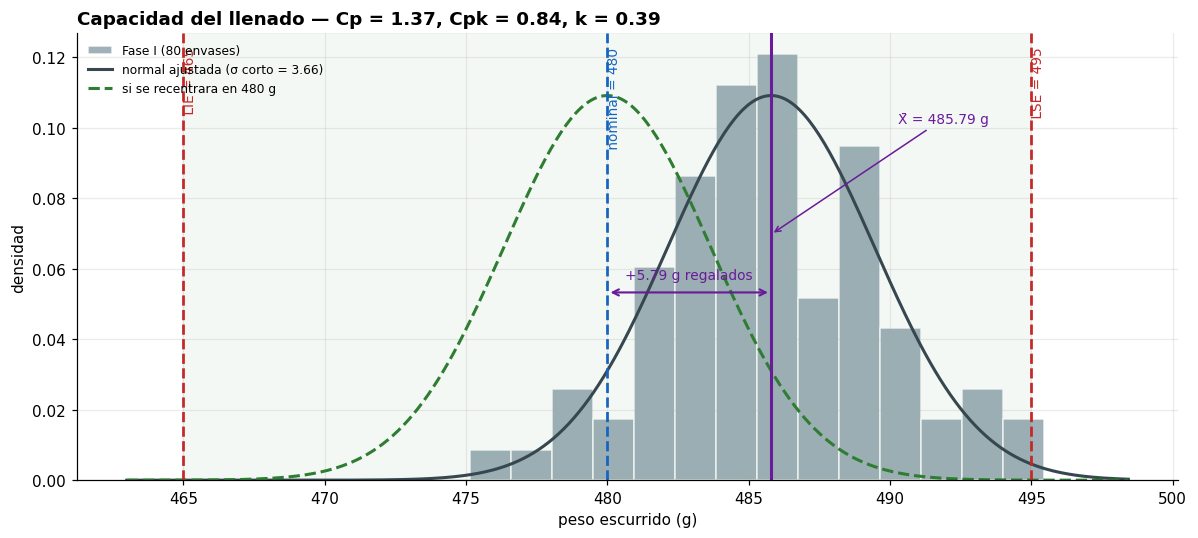

In [10]:
x = fase1["peso_g"].values
rejilla = np.linspace(min(LIE - 2, x.min() - 3), max(LSE + 2, x.max() + 3), 400)

fig, ax = plt.subplots(figsize=(11, 5))

ax.hist(x, bins=14, density=True, color="#90a4ae", edgecolor="white",
        alpha=0.85, label=f"Fase I ({len(x)} envases)")
ax.plot(rejilla, stats.norm.pdf(rejilla, xbb, sigma_corto), color="#37474f",
        lw=2, label=f"normal ajustada (σ corto = {sigma_corto:.2f})")
ax.plot(rejilla, stats.norm.pdf(rejilla, CENTRO_ESPEC, sigma_corto),
        color="#2e7d32", lw=2, ls="--",
        label="si se recentrara en 480 g")

ax.axvspan(LIE, LSE, color="#2e7d32", alpha=0.05)
for v, col, txt in [(LIE, "#c62828", f"LIE = {LIE:.0f}"),
                    (LSE, "#c62828", f"LSE = {LSE:.0f}"),
                    (NOMINAL, "#1565c0", f"nominal = {NOMINAL:.0f}")]:
    ax.axvline(v, color=col, lw=1.8, ls="--")
    ax.text(v, ax.get_ylim()[1] * 0.97, f" {txt}", color=col, fontsize=9,
            rotation=90, va="top")

ax.axvline(xbb, color="#6a1b9a", lw=2)
ax.annotate(f"X̄̄ = {xbb:.2f} g",
            xy=(xbb, ax.get_ylim()[1] * 0.55),
            xytext=(xbb + 4.5, ax.get_ylim()[1] * 0.80),
            color="#6a1b9a", fontsize=9,
            arrowprops=dict(arrowstyle="->", color="#6a1b9a"))
ax.annotate("", xy=(NOMINAL, ax.get_ylim()[1] * 0.42),
            xytext=(xbb, ax.get_ylim()[1] * 0.42),
            arrowprops=dict(arrowstyle="<->", color="#6a1b9a", lw=1.4))
ax.text((NOMINAL + xbb) / 2, ax.get_ylim()[1] * 0.45,
        f"+{sobrepeso:.2f} g regalados", ha="center", color="#6a1b9a",
        fontsize=9)

ax.set_title(f"Capacidad del llenado — Cp = {Cp:.2f}, Cpk = {Cpk:.2f}, "
             f"k = {k:.2f}", loc="left")
ax.set_xlabel("peso escurrido (g)")
ax.set_ylabel("densidad")
ax.legend(loc="upper left", fontsize=8)

figura(fig, "capacidad_histograma")
plt.show()

La campana verde punteada es el contrafactual: misma forma, movida al centro.
Se ve que no se gana ancho —Cp no cambia— pero las dos colas quedan
simétricas y lejos de los límites. Es literalmente el mismo proceso, corrido.

## 10. Comprobación contra las cifras de referencia

In [11]:
print("Comprobación:")
ok = [
    verificar(sigma_corto, 3.655, "sigma corto plazo"),
    verificar(sigma_largo, 3.962, "sigma largo plazo"),
    verificar(Cp, 1.368, "Cp"),
    verificar(Cpu, 0.840, "Cpu"),
    verificar(Cpl, 1.896, "Cpl"),
    verificar(Cpk, 0.840, "Cpk"),
    verificar(Pp, 1.262, "Pp"),
    verificar(Ppk, 0.775, "Ppk"),
    verificar(k, 0.386, "k (descentrado)", tol=1e-2),
    verificar(ppm_total, 5891, "PPM total esperado", tol=1e-3),
    verificar(sobrepeso, 5.79, "sobrepeso medio (g)", tol=1e-2),
    verificar(ppm_centrado, 41, "PPM al recentrar", tol=1e-2),
]
print(f"\n{sum(ok)}/{len(ok)} comprobaciones correctas")
assert all(ok), "alguna comprobación no reprodujo la cifra de referencia"

indices = pd.DataFrame([
    dict(indice="Cp", valor=Cp, sigma="corto (R̄/d₂)"),
    dict(indice="Cpu", valor=Cpu, sigma="corto (R̄/d₂)"),
    dict(indice="Cpl", valor=Cpl, sigma="corto (R̄/d₂)"),
    dict(indice="Cpk", valor=Cpk, sigma="corto (R̄/d₂)"),
    dict(indice="Pp", valor=Pp, sigma="largo (s muestral)"),
    dict(indice="Ppk", valor=Ppk, sigma="largo (s muestral)"),
    dict(indice="k", valor=k, sigma="—"),
])
tabla(indices, "indices_capacidad")
tabla(escenarios, "escenarios_capacidad")
resumen({"sigma_corto": sigma_corto, "sigma_largo": sigma_largo,
         "Cp": Cp, "Cpu": Cpu, "Cpl": Cpl, "Cpk": Cpk,
         "Pp": Pp, "Ppk": Ppk, "k": k, "Cp_sobre_Cpk": Cp / Cpk,
         "ppm_sup": ppm_sup, "ppm_inf": ppm_inf, "ppm_total": ppm_total,
         "ppm_recentrado": ppm_centrado, "sobrepeso_g": sobrepeso,
         "kg_regalados_anio": kg_regalados},
        "resumen_capacidad")
print("\nGuardado en resultados/")

Comprobación:
  [  OK  ] sigma corto plazo: obtenido 3.6552 | referencia 3.6550 | dif. relativa 4.72e-05
  [  OK  ] sigma largo plazo: obtenido 3.9619 | referencia 3.9620 | dif. relativa 2.51e-05
  [  OK  ] Cp: obtenido 1.3679 | referencia 1.3680 | dif. relativa 5.52e-05
  [  OK  ] Cpu: obtenido 0.8395 | referencia 0.8400 | dif. relativa 4.59e-04
  [  OK  ] Cpl: obtenido 1.8963 | referencia 1.8960 | dif. relativa 1.63e-04
  [  OK  ] Cpk: obtenido 0.8395 | referencia 0.8400 | dif. relativa 4.59e-04
  [  OK  ] Pp: obtenido 1.2620 | referencia 1.2620 | dif. relativa 1.63e-05
  [  OK  ] Ppk: obtenido 0.7745 | referencia 0.7750 | dif. relativa 4.56e-04
  [  OK  ] k (descentrado): obtenido 0.3863 | referencia 0.3860 | dif. relativa 2.67e-04
  [  OK  ] PPM total esperado: obtenido 5,890.7487 | referencia 5,891.0000 | dif. relativa 4.27e-05
  [  OK  ] sobrepeso medio (g): obtenido 5.7940 | referencia 5.7900 | dif. relativa 6.91e-04
  [  OK  ] PPM al recentrar: obtenido 40.6465 | referencia 41.

---

## Para llevarse

1. **Cp mide el ancho; Cpk mide el ancho y el centrado.** Cp no contiene la
   media, así que un proceso angosto y mal ubicado puede tener Cp excelente y
   rechazar todo. Los dos índices juntos, o mejor la pareja (Cp, k), dicen
   cuál de los dos problemas hay.
2. **Cp/Cpk = 1,63 cuantifica el descentrado.** No es que falte capacidad: el
   proceso ya la tiene y se está perdiendo el 39 % en el centrado.
3. **Recentrar es gratis comparado con reducir σ.** Mover la media 5,79 g
   lleva el PPM de 5 891 a 41; lograr lo mismo reduciendo la variabilidad
   exigiría llevar σ de 3,66 a ~1,9 g, que es un proyecto de inversión.
4. **El sobrepeso es una decisión, no un error.** La planta regala 5,79 g por
   envase como seguro contra el mínimo legal. Ese seguro tiene precio y se
   puede dimensionar: la pregunta correcta no es «¿sobrellenamos?» sino
   «¿cuánto, y con qué riesgo residual?».

## Ejercicios

1. Recalcule Cp, Cpk y el PPM usando **todos** los 30 subgrupos en lugar de
   solo la Fase I. ¿Cuánto cambia cada índice? Explique por qué el número que
   obtiene no describe ningún proceso real, y qué habría que hacer antes de
   poder reportar una capacidad.
2. El objetivo de 480 g deja la mitad de los envases bajo el peso declarado.
   Busque el objetivo μ* que hace que la probabilidad de caer bajo el LIE sea
   a lo más 1 por millón, manteniendo σ = 3,655 g. Calcule con ese μ* el Cpk,
   el PPM total y el sobrepeso que se sigue regalando. Compare el ahorro anual
   con el del escenario de 480 g.
3. Suponga que se decide invertir en la máquina en lugar de recentrar. ¿Qué
   valor de σ se necesita para alcanzar Cpk = 1,33 **sin mover la media de
   485,79 g**? Resuelva la ecuación, y luego compare ese σ con el valor actual
   y con el de la mejor máquina disponible en el mercado (suponga 2,5 g).
   ¿Alcanza la inversión, o hay que recentrar de todos modos?